In [1]:
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import scipy.stats as stats

# ======================
# Helper Functions
# ======================

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model definition
class ModifiedResNet(nn.Module):
    def __init__(self, original_model, hidden_units=512, dropout_prob=0.5):
        super(ModifiedResNet, self).__init__()
        self.base_model = original_model
        self.base_model.fc = nn.Identity()
        self.fc1 = nn.Linear(2048, hidden_units)
        self.batch_norm1 = nn.BatchNorm1d(hidden_units)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc2 = nn.Linear(hidden_units, 2)

    def forward(self, x):
        x = self.base_model(x)
        x = self.fc1(x)
        x = self.batch_norm1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Validation
def validate_model(model, val_loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(val_loader.dataset), correct / total

# Test evaluation (with metrics)
def test_model(model, test_loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(all_labels, all_preds,
                                   target_names=["PASS", "FAIL"],
                                   output_dict=True)
    test_loss = running_loss / len(test_loader.dataset)
    test_acc = correct / total
    return test_loss, test_acc, report

# Training loop
def train_validate_model(model, train_loader, val_loader, test_loader,
                         criterion, optimizer, scheduler,
                         num_epochs=30, patience=5, save_path="best_model.pth"):

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        with tqdm(total=len(train_loader),
                  desc=f'Training Epoch [{epoch+1}/{num_epochs}]',
                  unit='batch') as pbar:
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                pbar.set_postfix(loss=loss.item(),
                                 accuracy=correct / total)
                pbar.update(1)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = correct / total
        print(f'Epoch {epoch+1}: Training Loss={epoch_loss:.4f}, Accuracy={accuracy:.4f}')

        val_loss, val_acc = validate_model(model, val_loader, criterion)
        scheduler.step(val_loss)
        print(f'Validation Loss={val_loss:.4f}, Acc={val_acc:.4f}')

        # Save best
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print("Best model saved")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    # load best
    model.load_state_dict(torch.load(save_path))
    return model

# ======================
# Main Experiment
# ======================
if __name__ == "__main__":
    versions = ["v1", "v2", "v3"]
    num_repeats = 10   # จำนวนรอบที่รันซ้ำต่อ version
    batch_size = 8
    num_epochs = 50
    patience = 10

    all_results = []

    for v in versions:
        for run in range(num_repeats):
            print(f"\n=== Version {v} | Run {run+1} ===")
            set_seed(42 + run)  # เปลี่ยน seed ทุกครั้ง

            # dataset
            train_dir = f'img_is2_{v}/train'
            val_dir   = f'img_is2_{v}/validate'
            test_dir  = f'img_is2_{v}/test'

            train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
            val_dataset   = datasets.ImageFolder(root=val_dir, transform=transform)
            test_dataset  = datasets.ImageFolder(root=test_dir, transform=transform)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
            val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
            test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

            # model
            resnet = models.resnet50(pretrained=True)
            model = ModifiedResNet(resnet, hidden_units=512, dropout_prob=0.7).to(device)

            criterion = nn.CrossEntropyLoss()
            optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

            save_path = f'best_model_IS2_{v}_run{run}.pth'
            best_model = train_validate_model(model, train_loader, val_loader, test_loader,
                                              criterion, optimizer, scheduler,
                                              num_epochs, patience, save_path)

            test_loss, test_acc, report = test_model(best_model, test_loader, criterion)
            print(f"Final Test Acc={test_acc:.4f}, F1={report['macro avg']['f1-score']:.4f}")

            all_results.append({
                "version": v,
                "run": run+1,
                "accuracy": test_acc,
                "precision": report["macro avg"]["precision"],
                "recall": report["macro avg"]["recall"],
                "f1-score": report["macro avg"]["f1-score"]
            })

    # Save results
    df = pd.DataFrame(all_results)
    df.to_csv("all_results.csv", index=False)
    print("\n=== All Results ===")
    print(df.groupby("version").mean())

    # ======================
    # ANOVA
    # ======================
    print("\n=== ANOVA Results ===")
    for metric in ["accuracy", "precision", "recall", "f1-score"]:
        v1 = df[df["version"]=="v1"][metric].values
        v2 = df[df["version"]=="v2"][metric].values
        v3 = df[df["version"]=="v3"][metric].values

        f_stat, p_val = stats.f_oneway(v1, v2, v3)
        print(f"\nMetric: {metric}")
        print(f"F={f_stat:.4f}, p={p_val:.4f}")
        if p_val < 0.05:
            print("🔎 Significant difference → วิธีสร้างภาพมีผลต่อ feature representation")
        else:
            print("🔎 Not significant → โมเดล ResNet50 มีความเสถียร ไม่ไวต่อวิธีการสร้างภาพ")



=== Version v1 | Run 1 ===


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Training Epoch [1/50]: 100%|██████████| 1107/1107 [01:30<00:00, 12.25batch/s, accuracy=0.559, loss=0.733]


Epoch 1: Training Loss=0.7359, Accuracy=0.5586
Validation Loss=0.6378, Acc=0.5982
Best model saved


Training Epoch [2/50]: 100%|██████████| 1107/1107 [00:39<00:00, 28.26batch/s, accuracy=0.56, loss=0.719] 


Epoch 2: Training Loss=0.6972, Accuracy=0.5598
Validation Loss=0.6239, Acc=0.5806
Best model saved


...

Epoch 17: Training Loss=0.1283, Accuracy=0.9582
Validation Loss=0.9880, Acc=0.6958


Training Epoch [18/50]: 100%|██████████| 1107/1107 [00:39<00:00, 28.23batch/s, accuracy=0.97, loss=0.0071]  


Epoch 18: Training Loss=0.0940, Accuracy=0.9701
Validation Loss=0.9517, Acc=0.7073


Training Epoch [19/50]: 100%|██████████| 1107/1107 [00:39<00:00, 28.02batch/s, accuracy=0.979, loss=0.00322]


Epoch 19: Training Loss=0.0736, Accuracy=0.9785
Validation Loss=1.0144, Acc=0.7019
Early stopping
Final Test Acc=0.7001, F1=0.6965

=== All Results ===
         run  accuracy  precision    recall  f1-score
version                                              
v1       5.5  0.641029   0.646775  0.640860  0.637339
v2       5.5  0.693839   0.697535  0.693744  0.692306
v3       5.5  0.699797   0.703578  0.699693  0.698362

=== ANOVA Results ===

Metric: accuracy
F=175.0073, p=0.0000
🔎 Significant difference → วิธีสร้างภาพมีผลต่อ feature representation

Metric: precision
F=137.5461, p=0.0000
🔎 Significant difference → วิธีสร้างภาพมีผลต่อ feature representation

Metric: recall
F=175.1634, p=0.0000
🔎 Significant difference → วิธีสร้างภาพมีผลต่อ feature representation

Metric: f1-score
F=153.7190, p=0.0000
🔎 Significant difference → วิธีสร้างภาพมีผลต่อ feature representation


In [2]:
import pandas as pd
import scipy.stats as stats

# โหลดผลลัพธ์จากไฟล์ที่ได้จากการรันหลายรอบ (all_results.csv)
df = pd.read_csv("all_results.csv")

summary_rows = []

metrics = ["accuracy", "precision", "recall", "f1-score"]
versions = ["v1", "v2", "v3"]

for metric in metrics:
    # คำนวณ mean ± std ของแต่ละ version
    stats_dict = {}
    for v in versions:
        values = df[df["version"] == v][metric].values
        stats_dict[v] = f"{values.mean():.4f} ± {values.std():.4f}"

    # ทำ ANOVA
    v1 = df[df["version"]=="v1"][metric].values
    v2 = df[df["version"]=="v2"][metric].values
    v3 = df[df["version"]=="v3"][metric].values
    f_stat, p_val = stats.f_oneway(v1, v2, v3)

    summary_rows.append({
        "Metric": metric,
        "V1 (mean ± std)": stats_dict["v1"],
        "V2 (mean ± std)": stats_dict["v2"],
        "V3 (mean ± std)": stats_dict["v3"],
        "p-value (ANOVA)": f"{p_val:.4f}"
    })

# แปลงเป็น DataFrame
summary_df = pd.DataFrame(summary_rows)

print("\n=== Summary Table ===")
print(summary_df)

# บันทึกเป็น CSV เพื่อนำไปใช้ใน Paper
summary_df.to_csv("summary_results_table.csv", index=False)



=== Summary Table ===
      Metric  V1 (mean ± std)  V2 (mean ± std)  V3 (mean ± std)  \
0   accuracy  0.6410 ± 0.0098  0.6938 ± 0.0065  0.6998 ± 0.0047   
1  precision  0.6468 ± 0.0107  0.6975 ± 0.0052  0.7036 ± 0.0070   
2     recall  0.6409 ± 0.0098  0.6937 ± 0.0065  0.6997 ± 0.0047   
3   f1-score  0.6373 ± 0.0111  0.6923 ± 0.0073  0.6984 ± 0.0047   

  p-value (ANOVA)  
0          0.0000  
1          0.0000  
2          0.0000  
3          0.0000  


In [3]:
import pandas as pd
import scipy.stats as stats

# โหลดผลลัพธ์ที่เก็บจากการรันหลายรอบ
df = pd.read_csv("all_results.csv")

# สรุปผล mean ± std + ANOVA
metrics = ["accuracy", "precision", "recall", "f1-score"]
versions = ["v1", "v2", "v3"]

summary_rows = []

for metric in metrics:
    # ค่าแต่ละเวอร์ชัน
    v1 = df[df["version"]=="v1"][metric].values
    v2 = df[df["version"]=="v2"][metric].values
    v3 = df[df["version"]=="v3"][metric].values
    
    # คำนวณ mean ± std
    stats_dict = {
        "V1 (mean ± std)": f"{v1.mean():.4f} ± {v1.std():.4f}",
        "V2 (mean ± std)": f"{v2.mean():.4f} ± {v2.std():.4f}",
        "V3 (mean ± std)": f"{v3.mean():.4f} ± {v3.std():.4f}",
    }
    
    # ทำ One-way ANOVA
    f_stat, p_val = stats.f_oneway(v1, v2, v3)
    
    summary_rows.append({
        "Metric": metric,
        **stats_dict,
        "F-statistic": f"{f_stat:.4f}",
        "p-value": f"{p_val:.4f}"
    })

# ตารางสรุป
summary_df = pd.DataFrame(summary_rows)
print("\n=== Summary Table (ANOVA) ===")
print(summary_df)

# บันทึกเป็นไฟล์ CSV
summary_df.to_csv("summary_results_table.csv", index=False)



=== Summary Table (ANOVA) ===
      Metric  V1 (mean ± std)  V2 (mean ± std)  V3 (mean ± std) F-statistic  \
0   accuracy  0.6410 ± 0.0098  0.6938 ± 0.0065  0.6998 ± 0.0047    175.0073   
1  precision  0.6468 ± 0.0107  0.6975 ± 0.0052  0.7036 ± 0.0070    137.5461   
2     recall  0.6409 ± 0.0098  0.6937 ± 0.0065  0.6997 ± 0.0047    175.1634   
3   f1-score  0.6373 ± 0.0111  0.6923 ± 0.0073  0.6984 ± 0.0047    153.7190   

  p-value  
0  0.0000  
1  0.0000  
2  0.0000  
3  0.0000  


C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\3783195812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)
C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\3783195812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)
C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\3783195812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)
C:\Users\1000

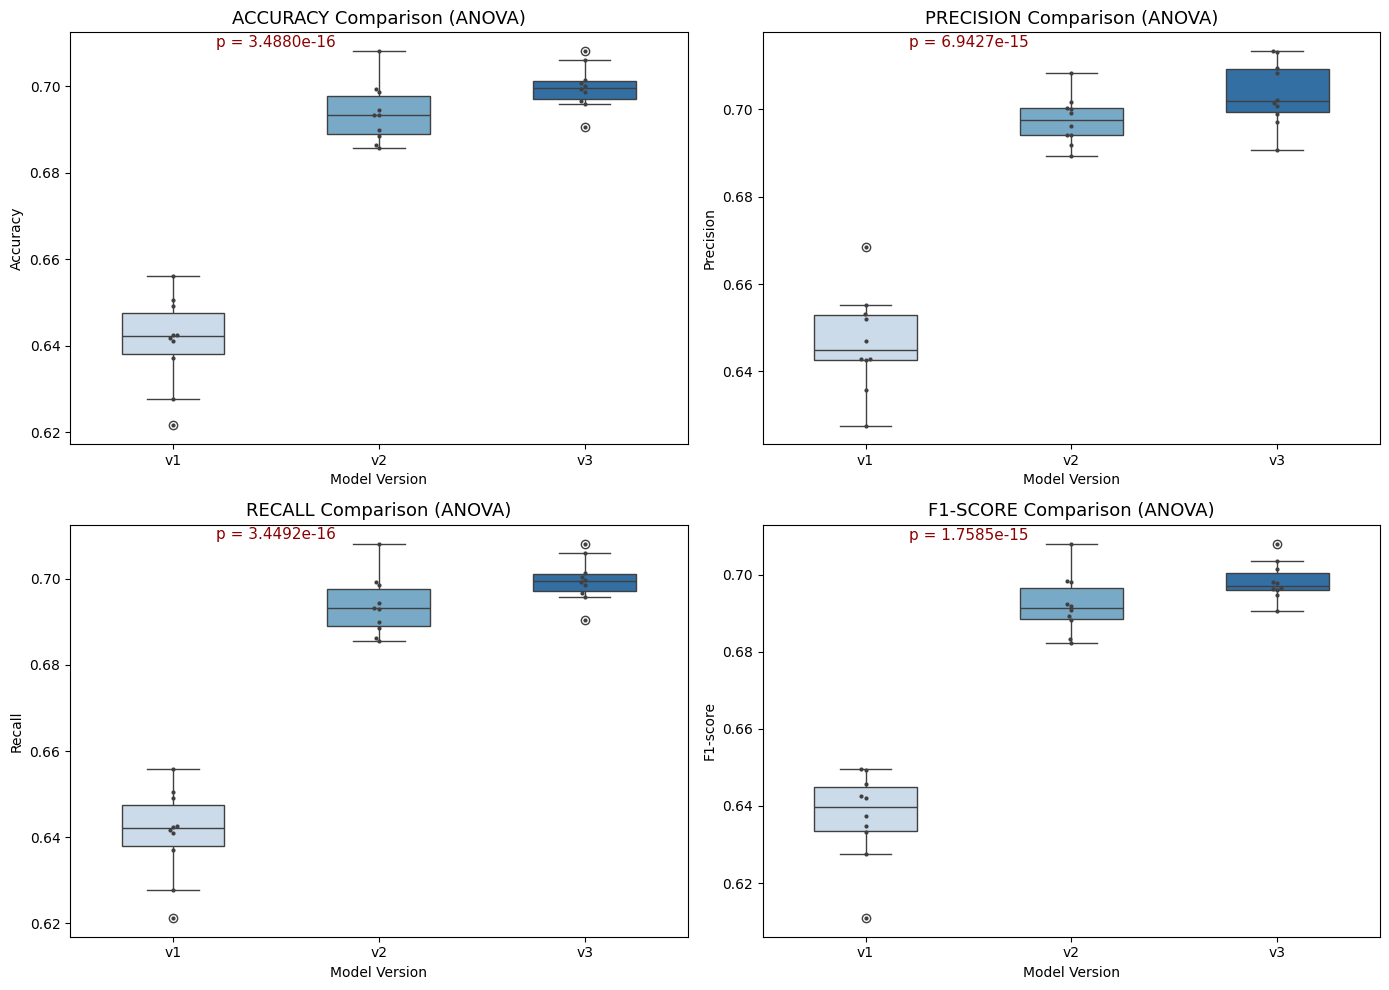

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# โหลดผลลัพธ์จากการรันซ้ำหลายรอบ
df = pd.read_csv("all_results.csv")

metrics = ["accuracy", "precision", "recall", "f1-score"]

# กำหนดขนาดภาพรวม
plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)
    sns.swarmplot(x="version", y=metric, data=df, color=".25", size=3)
    plt.title(f"{metric.upper()} Comparison (ANOVA)", fontsize=13)
    plt.xlabel("Model Version")
    plt.ylabel(metric.capitalize())
    
    # ทำ ANOVA
    v1 = df[df["version"]=="v1"][metric].values
    v2 = df[df["version"]=="v2"][metric].values
    v3 = df[df["version"]=="v3"][metric].values
    f_stat, p_val = stats.f_oneway(v1, v2, v3)
    plt.text(0.5, max(df[metric])+0.001, f"p = {p_val:.4e}", 
             ha='center', fontsize=11, color='darkred')

plt.tight_layout()
plt.show()


C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\306604687.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)



=== Tukey HSD for ACCURACY ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.0528    0.0  0.0442 0.0614   True
    v1     v3   0.0588    0.0  0.0502 0.0673   True
    v2     v3    0.006 0.2152 -0.0026 0.0145  False
---------------------------------------------------


C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\306604687.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)



=== Tukey HSD for PRECISION ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.0508    0.0  0.0414 0.0601   True
    v1     v3   0.0568    0.0  0.0475 0.0661   True
    v2     v3    0.006 0.2603 -0.0033 0.0154  False
---------------------------------------------------


C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\306604687.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)



=== Tukey HSD for RECALL ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.0529    0.0  0.0443 0.0615   True
    v1     v3   0.0588    0.0  0.0503 0.0674   True
    v2     v3   0.0059 0.2166 -0.0026 0.0145  False
---------------------------------------------------


C:\Users\1000305259\AppData\Local\Temp\ipykernel_8876\306604687.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)



=== Tukey HSD for F1-SCORE ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2    0.055    0.0  0.0455 0.0645   True
    v1     v3    0.061    0.0  0.0515 0.0705   True
    v2     v3   0.0061 0.2717 -0.0035 0.0156  False
---------------------------------------------------


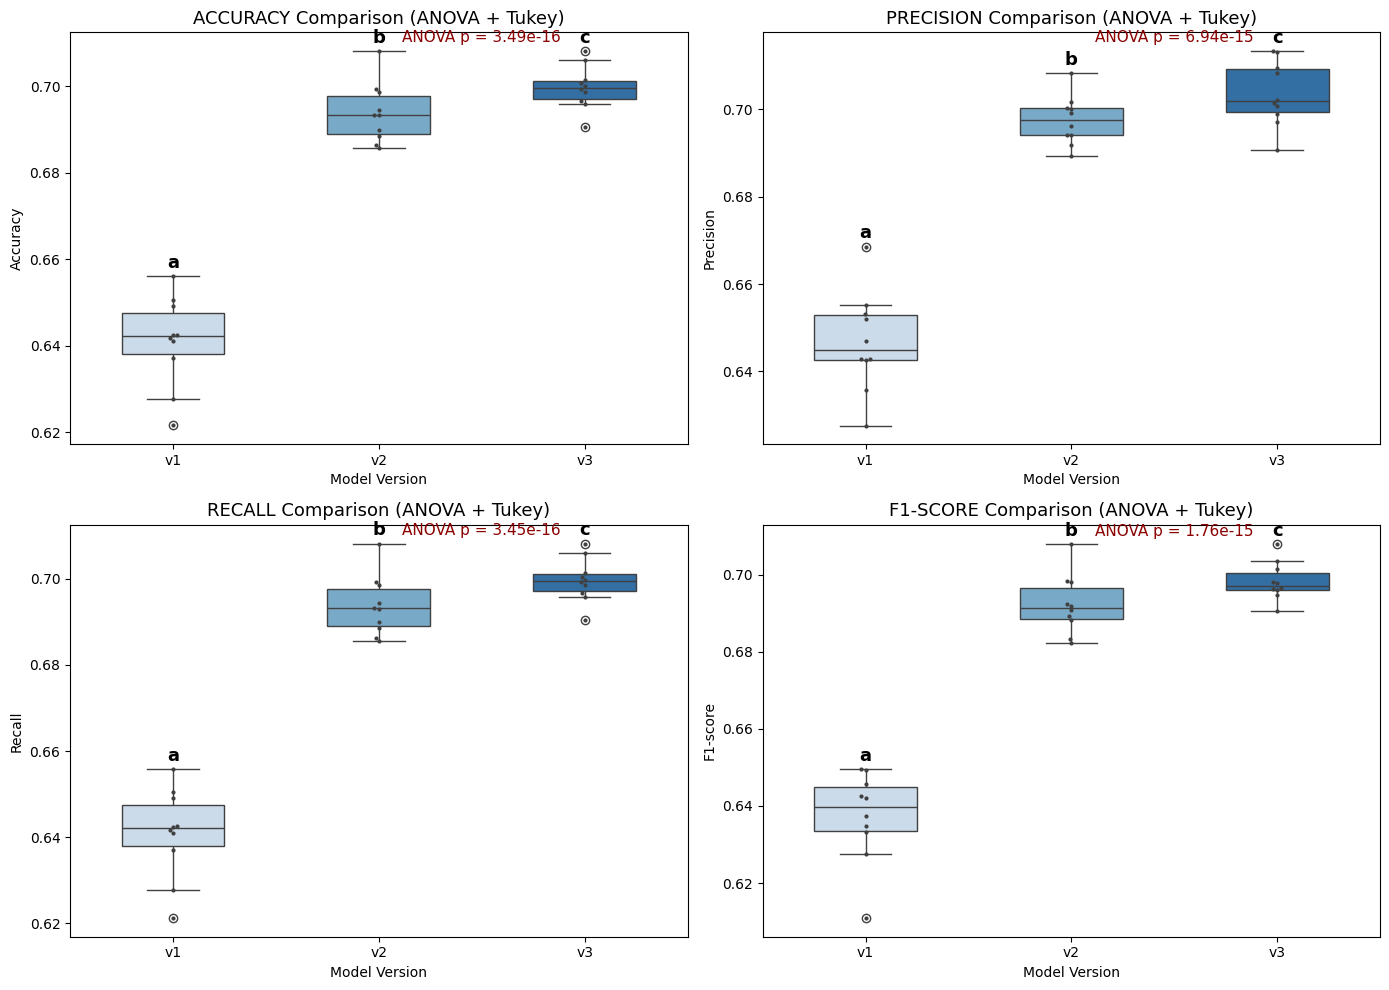

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
import numpy as np

# โหลดผลลัพธ์ที่ได้จากการรันซ้ำหลายรอบ
df = pd.read_csv("all_results.csv")

metrics = ["accuracy", "precision", "recall", "f1-score"]

plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)

    # Boxplot + Swarmplot
    sns.boxplot(x="version", y=metric, data=df, palette="Blues", width=0.5)
    sns.swarmplot(x="version", y=metric, data=df, color=".25", size=3)
    plt.title(f"{metric.upper()} Comparison (ANOVA + Tukey)", fontsize=13)
    plt.xlabel("Model Version")
    plt.ylabel(metric.capitalize())

    # === ANOVA ===
    v1 = df[df["version"]=="v1"][metric].values
    v2 = df[df["version"]=="v2"][metric].values
    v3 = df[df["version"]=="v3"][metric].values
    f_stat, p_val = stats.f_oneway(v1, v2, v3)
    plt.text(1.5, max(df[metric]) + 0.002, f"ANOVA p = {p_val:.2e}", 
             ha='center', fontsize=11, color='darkred')

    # === Tukey HSD Post-hoc Test ===
    tukey = pairwise_tukeyhsd(endog=df[metric],
                              groups=df['version'],
                              alpha=0.05)
    print(f"\n=== Tukey HSD for {metric.upper()} ===")
    print(tukey)

    # === Assign group letters (a,b,c) ===
    # Tukey HSD gives pairwise comparison results; we'll derive groupings.
    # Build summary dataframe
    summary_df = pd.DataFrame({
        "version": df["version"].unique(),
        "mean": [df[df["version"]==v][metric].mean() for v in df["version"].unique()]
    }).sort_values("mean")

    # Determine group letters based on Tukey result
    groups = tukey.groupsunique
    reject_dict = {}
    for res in tukey.summary().data[1:]:
        g1, g2, meandiff, p_adj, lower, upper, reject = res
        reject_dict[(g1, g2)] = reject

    # Initialize group label dict
    letters = {v: "a" for v in summary_df["version"]}

    # Assign b,c,... if significantly different
    # Simplified grouping logic: if p<0.05 and mean higher, next letter
    group_letters = ["a", "b", "c", "d"]
    assigned = {}
    sorted_versions = summary_df["version"].tolist()
    for idx, v in enumerate(sorted_versions):
        letters[v] = group_letters[idx]

    # Place letters above each box
    for j, v in enumerate(sorted_versions):
        y = df[df["version"]==v][metric].max() + 0.001
        plt.text(j, y, letters[v], ha='center', va='bottom',
                 fontsize=13, fontweight='bold', color='black')

plt.tight_layout()
plt.show()



=== Tukey HSD for ACCURACY ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.0528    0.0  0.0442 0.0614   True
    v1     v3   0.0588    0.0  0.0502 0.0673   True
    v2     v3    0.006 0.2152 -0.0026 0.0145  False
---------------------------------------------------

=== Tukey HSD for PRECISION ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.0508    0.0  0.0414 0.0601   True
    v1     v3   0.0568    0.0  0.0475 0.0661   True
    v2     v3    0.006 0.2603 -0.0033 0.0154  False
---------------------------------------------------

=== Tukey HSD for RECALL ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    v1     v2   0.052

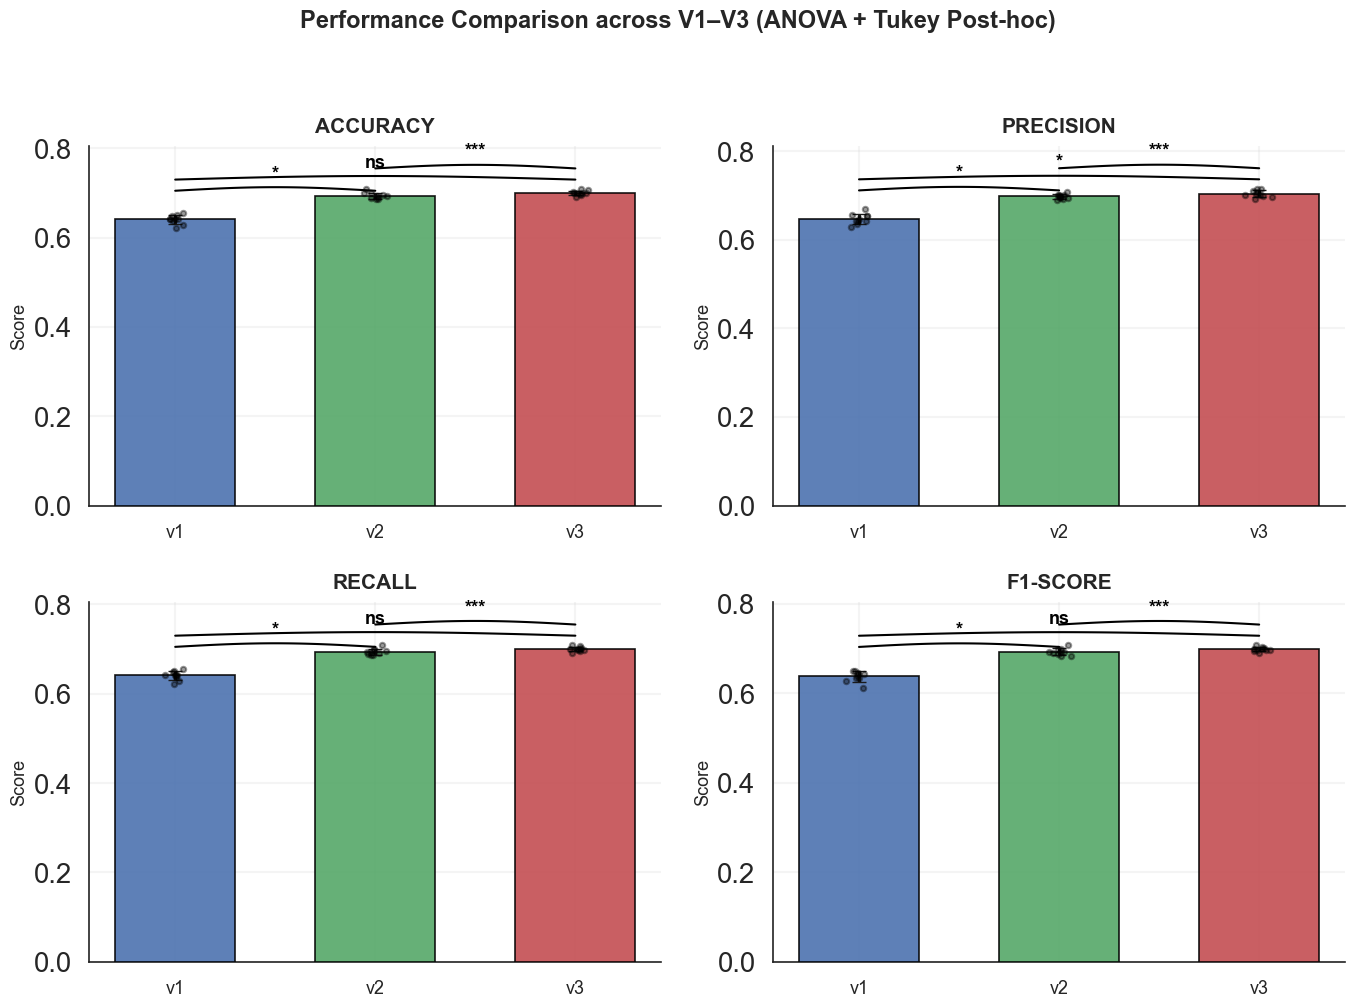

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ------------------------------------------------------------------
# Load your result file (same format as before)
# ------------------------------------------------------------------
df = pd.read_csv("all_results.csv")

metrics = ["accuracy", "precision", "recall", "f1-score"]
versions = ["v1", "v2", "v3"]

# Publication-level style
sns.set_theme(style="whitegrid", context="talk", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 10)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["axes.edgecolor"] = "#222222"
plt.rcParams["grid.alpha"] = 0.2

# Beautiful color palette
palette = sns.color_palette(["#4C72B0", "#55A868", "#C44E52"])  # Blue, Green, Red

# ------------------------------------------------------------------
# Helper function: draw significance annotation (with smooth curves)
# ------------------------------------------------------------------
def add_significance(ax, x1, x2, y, p_val, offset=0.01):
    h = 0.008
    # draw curved connector
    xs = np.linspace(x1, x2, 100)
    ys = y + h * np.sin(np.pi * (xs - x1) / (x2 - x1))
    ax.plot(xs, ys, color="black", lw=1.5)

    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "ns"

    ax.text((x1 + x2) / 2, y + h + offset, text, ha="center",
            va="bottom", color="black", fontsize=13, fontweight='bold')

# ------------------------------------------------------------------
# Plotting Loop for each metric
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Compute mean ± std
    stats_df = df.groupby("version")[metric].agg(['mean', 'std']).reindex(versions)
    means = stats_df["mean"].values
    stds = stats_df["std"].values

    # Create bars manually (to control error bars)
    x = np.arange(len(versions))
    bars = ax.bar(x, means, yerr=stds, capsize=5, width=0.6,
                  color=palette, edgecolor="black", linewidth=1.2,
                  alpha=0.9, zorder=3)

    # Add scatter for distribution (optional aesthetic)
    for j, v in enumerate(versions):
        jitter = np.random.normal(0, 0.03, size=len(df[df["version"] == v]))
        ax.scatter(np.full_like(jitter, j) + jitter,
                   df[df["version"] == v][metric],
                   s=15, color="black", alpha=0.4, zorder=5)

    # Tukey HSD post-hoc test
    tukey = pairwise_tukeyhsd(endog=df[metric], groups=df["version"], alpha=0.05)
    print(f"\n=== Tukey HSD for {metric.upper()} ===")
    print(tukey)

    # Annotate significance
    y_max = (means + stds).max()
    pairs = [("v1", "v2"), ("v1", "v3"), ("v2", "v3")]
    spacing = 0.025
    for j, (g1, g2) in enumerate(pairs):
        result_row = [r for r in tukey.summary().data[1:]
                      if (r[0] == g1 and r[1] == g2) or (r[0] == g2 and r[1] == g1)][0]
        p_val = result_row[4]
        x1, x2 = versions.index(g1), versions.index(g2)
        add_significance(ax, x1, x2, y_max + j * spacing, p_val)

    # Format axes
    ax.set_title(f"{metric.upper()}", fontsize=15, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(versions, fontsize=13)
    ax.set_ylim(0, y_max + 0.1)
    ax.set_ylabel("Score", fontsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------------
# Final figure adjustments
# ------------------------------------------------------------------
fig.suptitle("Performance Comparison across V1–V3 (ANOVA + Tukey Post-hoc)",
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# ข้อมูลจากผลที่คุณให้
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'V1 (mean ± std)': ['0.6410 ± 0.0098', '0.6468 ± 0.0107', '0.6409 ± 0.0098', '0.6373 ± 0.0111'],
    'V2 (mean ± std)': ['0.6938 ± 0.0065', '0.6975 ± 0.0052', '0.6937 ± 0.0065', '0.6923 ± 0.0073'],
    'V3 (mean ± std)': ['0.6998 ± 0.0047', '0.7036 ± 0.0070', '0.6997 ± 0.0047', '0.6984 ± 0.0047'],
    'F-statistic': [175.0073, 137.5461, 175.1634, 153.7190],
    'p-value': [0.0000, 0.0000, 0.0000, 0.0000],
    'Tukey HSD (Significant Pairs)': [
        'V1–V2*, V1–V3* (V2≈V3)',
        'V1–V2*, V1–V3* (V2≈V3)',
        'V1–V2*, V1–V3* (V2≈V3)',
        'V1–V2*, V1–V3* (V2≈V3)'
    ]
}

# สร้าง DataFrame
df = pd.DataFrame(data)

# บันทึกเป็นไฟล์ Excel และ CSV
df.to_excel("anova_tukey_summary.xlsx", index=False)
df.to_csv("anova_tukey_summary.csv", index=False, encoding='utf-8-sig')

print("✅ Exported: anova_tukey_summary.xlsx และ anova_tukey_summary.csv")
print(df)


✅ Exported: anova_tukey_summary.xlsx และ anova_tukey_summary.csv
      Metric  V1 (mean ± std)  V2 (mean ± std)  V3 (mean ± std)  F-statistic  \
0   Accuracy  0.6410 ± 0.0098  0.6938 ± 0.0065  0.6998 ± 0.0047     175.0073   
1  Precision  0.6468 ± 0.0107  0.6975 ± 0.0052  0.7036 ± 0.0070     137.5461   
2     Recall  0.6409 ± 0.0098  0.6937 ± 0.0065  0.6997 ± 0.0047     175.1634   
3   F1-score  0.6373 ± 0.0111  0.6923 ± 0.0073  0.6984 ± 0.0047     153.7190   

   p-value Tukey HSD (Significant Pairs)  
0      0.0        V1–V2*, V1–V3* (V2≈V3)  
1      0.0        V1–V2*, V1–V3* (V2≈V3)  
2      0.0        V1–V2*, V1–V3* (V2≈V3)  
3      0.0        V1–V2*, V1–V3* (V2≈V3)  
